In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Hugging Face Pipeline
from transformers import pipeline

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
movies = pd.read_csv("IMDB_Dataset.csv")

In [3]:
movies.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
movies.shape

(50000, 2)

In [5]:
movies.dtypes

review       str
sentiment    str
dtype: object

In [6]:
movies.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
movies.duplicated().sum()

np.int64(418)

In [8]:
movies.drop_duplicates(inplace=True)

In [9]:
movies.duplicated().sum()

np.int64(0)

In [11]:
movies["sentiment"].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

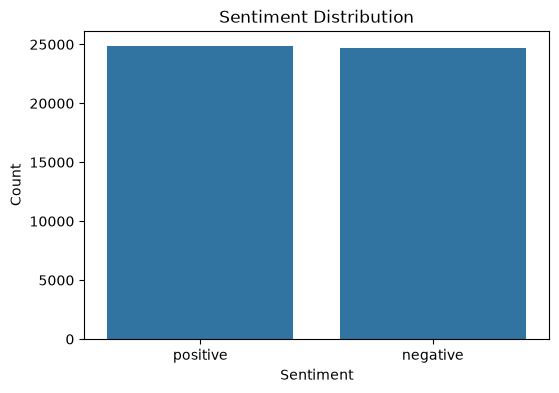

In [14]:
# visualization for class distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=movies,
    x="sentiment"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [20]:
movies.sample(5, random_state=42)

,review,sentiment
29171,"""Soul Plane"" is a horrible attempt at comedy t...",negative
43589,Guest from the Future tells a fascinating stor...,positive
38712,"""National Treasure"" (2004) is a thoroughly mis...",negative
16045,"OK. First said, I just wanted to check whether...",negative
5248,"I haven't always been a fan, but the show grew...",positive


In [21]:
movies["review_length"] = movies["review"].apply(len)

In [22]:
movies["review_length"].describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

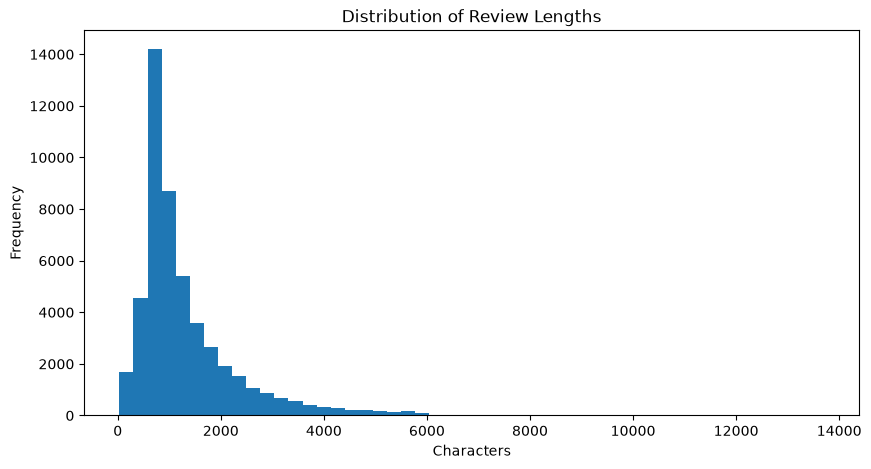

In [23]:
plt.figure(figsize=(10,5))

plt.hist(
    movies["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [26]:
# mapping the sentiment to numbers 
# positive -> 1.
# negative -> 0.

movies["label"] = movies["sentiment"].map({
    "negative": 0,
    "positive": 1
})

movies.head()

,review,sentiment,review_length,label
0,One of the other reviewers has mentioned that ...,positive,1761,1
1,A wonderful little production. <br /><br />The...,positive,998,1
2,I thought this was a wonderful way to spend ti...,positive,926,1
3,Basically there's a family where a little boy ...,negative,748,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,1


In [25]:
movies["label"].value_counts()

label
1    24884
0    24698
Name: count, dtype: int64

In [27]:
X = movies["review"]
y = movies["label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


In [30]:
from transformers import pipeline


In [31]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\dell\Desktop\AI-ML-Internship\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dell\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [32]:
# test

classifier("This movie was amazing!")

[{'label': 'POSITIVE', 'score': 0.9998800754547119}]

In [33]:
# test

classifier("THIS MOVIE WAS GARBAGE")

[{'label': 'NEGATIVE', 'score': 0.9998090863227844}]

In [35]:
# running predictions

sample_size = 1000

X_sample = X_test.iloc[:sample_size]
y_sample = y_test.iloc[:sample_size]

predictions = classifier(X_sample.tolist(), truncation=True)

In [36]:
y_pred = [
    1 if pred["label"] == "POSITIVE" else 0
    for pred in predictions
]

In [37]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_sample, y_pred)
f1 = f1_score(y_sample, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9000
F1-score: 0.8938
